objective is to build, test and validate a stock trading strategy; fec quant recruitment 

importing necessary libraries like yfinance,pandas,numpy etc etc

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
plt.style.use('default')
pd.set_option('display.max_columns', None)

PHASE 1 

loading stock data for past 7 yrs for tickers listed n checking on whether df isn't empty or something as for no backleashes further

In [2]:
tickers = ['AAPL','MSFT','NVDA','JPM','GS','CAT','XOM','PG','JNJ','PFE']
enddate = pd.Timestamp.now()
startdate = enddate - pd.DateOffset(years=7)
print(f"Starting data collection from {startdate.strftime('%Y-%m-%d')} to {enddate.strftime('%Y-%m-%d')}\n")
raw = yf.download(tickers, start=startdate, end=enddate, auto_adjust=False)
print(f"Data shape: {raw.shape}")
if raw.empty:
    raise ValueError("Download failed! The dataset is empty. Check your internet or ticker symbols.")
print(raw.head(5))

Starting data collection from 2019-05-30 to 2026-05-30



[*********************100%***********************]  10 of 10 completed

Data shape: (1759, 60)
Price       Adj Close                                                 \
Ticker           AAPL         CAT          GS         JNJ        JPM   
Date                                                                   
2019-05-31  41.877132  103.691406  155.552734  107.993927  87.615250   
2019-06-03  41.453751  104.418427  156.149475  108.232758  88.028702   
2019-06-04  42.970295  105.656029  161.851929  110.118408  90.740822   
2019-06-05  43.663975  106.556145  160.624481  110.653641  91.063309   
2019-06-06  44.305038  106.789787  161.792252  112.547516  91.261742   

Price                                                                  Close  \
Ticker            MSFT      NVDA        PFE         PG        XOM       AAPL   
Date                                                                           
2019-05-31  116.128044  3.365441  28.155052  86.224701  51.578842  43.767502   
2019-06-03  112.522499  3.323702  28.426294  86.970406  52.387852  43.325001   


cols r close,adj close,high,low,open,volume for each of ticker chosen
doing adjusted close on the col 'adj close' n extracting both the metric n volume ie the no of shares traded daily ie 'volume'

In [3]:
adj_close_df = raw['Adj Close']
volume_df = raw['Volume']
print(adj_close_df.tail(5))
print(volume_df.head(5))

Ticker            AAPL         CAT           GS         JNJ         JPM  \
Date                                                                      
2026-05-22  308.820007  879.890015   996.729980  233.000000  306.380005   
2026-05-26  308.329987  908.549988   994.520020  230.179993  306.739990   
2026-05-27  310.850006  909.929993   996.469971  231.289993  299.279999   
2026-05-28  312.510010  887.669983  1008.369995  230.800003  296.730011   
2026-05-29  312.059998  875.869995  1025.560059  225.330002  299.309998   

Ticker            MSFT        NVDA        PFE          PG         XOM  
Date                                                                   
2026-05-22  418.570007  215.330002  25.900000  144.440002  154.919998  
2026-05-26  416.029999  214.860001  25.850000  142.960007  149.809998  
2026-05-27  412.670013  212.600006  26.209999  147.490005  147.899994  
2026-05-28  426.989990  214.250000  26.139999  145.910004  146.960007  
2026-05-29  450.239990  211.139999  26.180

handling missing data n null values; checking for percentage null values first

In [4]:
print(adj_close_df.isnull().mean() * 100)
print(volume_df.isnull().mean() * 100)

Ticker
AAPL    0.0
CAT     0.0
GS      0.0
JNJ     0.0
JPM     0.0
MSFT    0.0
NVDA    0.0
PFE     0.0
PG      0.0
XOM     0.0
dtype: float64
Ticker
AAPL    0.0
CAT     0.0
GS      0.0
JNJ     0.0
JPM     0.0
MSFT    0.0
NVDA    0.0
PFE     0.0
PG      0.0
XOM     0.0
dtype: float64


here the null values arent present but running .ffill().bfill() to ensure no errors preexist here

In [5]:
adj_close_df = adj_close_df.ffill().bfill()
volume_df = volume_df.ffill().bfill()
print(adj_close_df.isnull().mean() * 100)
print(volume_df.isnull().mean() * 100)

Ticker
AAPL    0.0
CAT     0.0
GS      0.0
JNJ     0.0
JPM     0.0
MSFT    0.0
NVDA    0.0
PFE     0.0
PG      0.0
XOM     0.0
dtype: float64
Ticker
AAPL    0.0
CAT     0.0
GS      0.0
JNJ     0.0
JPM     0.0
MSFT    0.0
NVDA    0.0
PFE     0.0
PG      0.0
XOM     0.0
dtype: float64


In [6]:
print(adj_close_df.shape)
print(volume_df.shape)
print(adj_close_df.info())
print(volume_df.info())

(1759, 10)
(1759, 10)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1759 entries, 2019-05-31 to 2026-05-29
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    1759 non-null   float64
 1   CAT     1759 non-null   float64
 2   GS      1759 non-null   float64
 3   JNJ     1759 non-null   float64
 4   JPM     1759 non-null   float64
 5   MSFT    1759 non-null   float64
 6   NVDA    1759 non-null   float64
 7   PFE     1759 non-null   float64
 8   PG      1759 non-null   float64
 9   XOM     1759 non-null   float64
dtypes: float64(10)
memory usage: 151.2 KB
None
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1759 entries, 2019-05-31 to 2026-05-29
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   AAPL    1759 non-null   int64
 1   CAT     1759 non-null   int64
 2   GS      1759 non-null   int64
 3   JNJ     1759 non-null   int64
 4   JPM     1759 non-null

phase 1 is completed

PHASE 2

moving on to phase2, creating signals that tells algorithm whether a stock is worth buying or not or to be sold accordingly

keeping SMA,RSI,ATR,VWAP
as indicators as theyr perfect mix to ans whether the stock is going up, if it is currently cheap on short term basis, or is statstically at extreme offering safe enttry, n to identify whether the smart investors r actually participating in the uptrend

okay so when i implemented sma over 200 days; the thing was for starting days the table filled up with zeroes as here may 30, 2019 the first row of dataset was taken upon and looked backwards but theres no data present right so first 199 rows in 2019 were kinda warm up period and signals fire untill roughly march 2020

so the code below works just fine normally with its first 199 rows in 2019 as warmup period

In [7]:
adj_ratio = raw['Adj Close'] / raw['Close']
open_df = raw['Open'] * adj_ratio
adj_close_df = raw['Adj Close']
high_df = raw['High'] * adj_ratio
low_df = raw['Low'] * adj_ratio
volume_df = raw['Volume'].ffill().bfill()

# Filling data gaps to ensure seamless data coverage
open_df = open_df.ffill().bfill()
adj_close_df = adj_close_df.ffill().bfill()
high_df = high_df.ffill().bfill()
low_df = low_df.ffill().bfill()


# INDICATOR CALCULATIONS

# Macro Trend Smoothing (The Golden/Death Cross Components)
sma_50 = adj_close_df.rolling(window=50).mean()
sma_200 = adj_close_df.rolling(window=200).mean()

# Volume Weighted Average Price (VWAP) - Adjusted 20-Day Rolling
typical_price = (high_df + low_df + adj_close_df) / 3
vwap_df = (typical_price * volume_df).rolling(window=20).sum() / volume_df.rolling(window=20).sum()

# 14-Day Momentum (RSI)
delta = adj_close_df.diff()
gains = delta.clip(lower=0).ewm(com=13, min_periods=14).mean()
losses = (-1 * delta.clip(upper=0)).ewm(com=13, min_periods=14).mean()
rs = gains / losses
rsi_df = 100 - (100 / (1 + rs))

# 14-Day Volatility (ATR)
prev_close = adj_close_df.shift(1)
tr1 = high_df - low_df
tr2 = (high_df - prev_close).abs()
tr3 = (low_df - prev_close).abs()
tr = np.maximum(tr1, np.maximum(tr2, tr3))
atr_df = tr.rolling(window=14).mean()

# EXCLUSIVE SIGNAL GENERATION

# Initialising with NaN to track states
daily_signals = pd.DataFrame(np.nan, index=adj_close_df.index, columns=adj_close_df.columns)

# 1 (Buy): Golden Cross Confirmed AND Momentum is positive
buy_mask = (sma_50 > sma_200) & (rsi_df > 50)

# -1 (Sell/Short): Death Cross Confirmed (Active Shorting)
sell_mask = (sma_50 < sma_200)

# 0 (Hold Cash): Price falls below VWAP, but Golden Cross is still technically active
neutral_mask = (adj_close_df < vwap_df) & (sma_50 >= sma_200)

# Applying 1, -1, 0
daily_signals[buy_mask] = 1
daily_signals[sell_mask] = -1
daily_signals[neutral_mask] = 0

# Forward filling the signals so positions are held until a new signal triggers
daily_signals = daily_signals.ffill().fillna(0)

# Shift signals by 1 day to execute on the Next Day's Open (Prevents look-ahead bias)
final_execution_signals = daily_signals.shift(1).fillna(0)
print(final_execution_signals.tail(10))

Ticker      AAPL  CAT   GS  JNJ  JPM  MSFT  NVDA  PFE   PG  XOM
Date                                                           
2026-05-15   1.0  1.0  1.0  1.0 -1.0  -1.0   1.0  0.0 -1.0  1.0
2026-05-18   1.0  1.0  1.0  0.0 -1.0  -1.0   1.0  0.0 -1.0  1.0
2026-05-19   1.0  0.0  1.0  0.0 -1.0  -1.0   1.0  0.0 -1.0  1.0
2026-05-20   1.0  0.0  0.0  1.0 -1.0  -1.0   1.0  0.0 -1.0  1.0
2026-05-21   1.0  0.0  1.0  1.0 -1.0  -1.0   1.0  0.0 -1.0  1.0
2026-05-22   1.0  0.0  1.0  1.0 -1.0  -1.0   1.0  0.0 -1.0  1.0
2026-05-26   1.0  0.0  1.0  1.0 -1.0  -1.0   1.0  0.0 -1.0  1.0
2026-05-27   1.0  1.0  1.0  1.0 -1.0  -1.0   0.0  0.0 -1.0  0.0
2026-05-28   1.0  1.0  1.0  1.0 -1.0  -1.0   0.0  1.0 -1.0  0.0
2026-05-29   1.0  0.0  1.0  1.0 -1.0  -1.0   0.0  1.0 -1.0  0.0


In [8]:
print(final_execution_signals.head(10))

Ticker      AAPL  CAT   GS  JNJ  JPM  MSFT  NVDA  PFE   PG  XOM
Date                                                           
2019-05-31   0.0  0.0  0.0  0.0  0.0   0.0   0.0  0.0  0.0  0.0
2019-06-03   0.0  0.0  0.0  0.0  0.0   0.0   0.0  0.0  0.0  0.0
2019-06-04   0.0  0.0  0.0  0.0  0.0   0.0   0.0  0.0  0.0  0.0
2019-06-05   0.0  0.0  0.0  0.0  0.0   0.0   0.0  0.0  0.0  0.0
2019-06-06   0.0  0.0  0.0  0.0  0.0   0.0   0.0  0.0  0.0  0.0
2019-06-07   0.0  0.0  0.0  0.0  0.0   0.0   0.0  0.0  0.0  0.0
2019-06-10   0.0  0.0  0.0  0.0  0.0   0.0   0.0  0.0  0.0  0.0
2019-06-11   0.0  0.0  0.0  0.0  0.0   0.0   0.0  0.0  0.0  0.0
2019-06-12   0.0  0.0  0.0  0.0  0.0   0.0   0.0  0.0  0.0  0.0
2019-06-13   0.0  0.0  0.0  0.0  0.0   0.0   0.0  0.0  0.0  0.0


as mentioned earlier due to 200 day sma, the sma was evaluating nans till 199 days apporx n gave away 0s in the very beginning for 199 days of 2019; so the above was designed as such to gather historic data n confirm the macro trend

otherwise to evaluate the active performance n handle this problem, chopping off the periods before calculating the performance; the below code exhibits this

In [9]:
# INDICATOR CALCULATIONS 
# Macro Trend Smoothing 
sma_50 = adj_close_df.rolling(window=50, min_periods=50).mean()
sma_200 = adj_close_df.rolling(window=200, min_periods=200).mean()

# Volume Weighted Average Price (VWAP) - Adjusted 20-Day Rolling
typical_price = (high_df + low_df + adj_close_df) / 3
vwap_df = (typical_price * volume_df).rolling(window=20).sum() / volume_df.rolling(window=20).sum()

# 14-Day Momentum (RSI)
delta = adj_close_df.diff()
gains = delta.clip(lower=0).ewm(com=13, min_periods=14).mean()
losses = (-1 * delta.clip(upper=0)).ewm(com=13, min_periods=14).mean()
rs = gains / losses
rsi_14 = 100 - (100 / (1 + rs))

# 14-Day Volatility (ATR)
prev_close = adj_close_df.shift(1)
tr1 = high_df - low_df
tr2 = (high_df - prev_close).abs()
tr3 = (low_df - prev_close).abs()
tr = np.maximum(tr1, np.maximum(tr2, tr3))
atr_14 = tr.rolling(window=14).mean()

# EXCLUSIVE SIGNAL GENERATION & MACRO RISK LEVELS

# Initialize with NaN to easily forwardfill the hold state
target_positions = pd.DataFrame(np.nan, index=adj_close_df.index, columns=adj_close_df.columns)

# 1 (Long): Golden Cross Confirmed AND Momentum is positive
long_condition = (sma_50 > sma_200) & (rsi_14 > 50)

# -1 (Short): Death Cross Confirmed
short_condition = (sma_50 < sma_200)

# 0 (Flat/Cash): Price falls below VWAP, but Golden Cross is still technically active
flat_condition = (adj_close_df < vwap_df) & (sma_50 >= sma_200)

# Apply Conditions 
target_positions[long_condition] = 1
target_positions[short_condition] = -1
target_positions[flat_condition] = 0

# Forward fill the signals so positions hold until a new signal triggers
target_positions = target_positions.ffill().fillna(0)

# Shift signals by 1 day to execute on the Next Day's Open (Prevents look-ahead bias)
trade_signals = target_positions.shift(1).fillna(0)

# WIDENED RISK LEVELS FOR MACRO TRENDS
# Since we are holding for months now, we widen the stops to avoid normal weekly volatility.
stop_loss_levels = (adj_close_df - (3 * atr_14)).ffill().fillna(0)
take_profit_levels = (adj_close_df + (5 * atr_14)).ffill().fillna(0)

# THE CHOP (CRITICAL FIX: ALIGNING ALL ARRAYS)

# Slice off the 200-day burn-in period across ALL datasets simultaneously
# This guarantees every NumPy array will have the exact same number of rows for the backtester
active_index = trade_signals.index[200:]
trade_signals = trade_signals.loc[active_index]
close_df = adj_close_df.loc[active_index]
open_df = open_df.loc[active_index]
high_df = high_df.loc[active_index]
low_df = low_df.loc[active_index]
stop_loss_levels = stop_loss_levels.loc[active_index]
take_profit_levels = take_profit_levels.loc[active_index]
print(trade_signals.head(10))

Ticker      AAPL  CAT   GS  JNJ  JPM  MSFT  NVDA  PFE   PG  XOM
Date                                                           
2020-03-17   0.0  0.0  0.0  0.0  0.0   0.0   0.0 -1.0  0.0 -1.0
2020-03-18   0.0  0.0  0.0  0.0  0.0   0.0   0.0 -1.0  0.0 -1.0
2020-03-19   0.0 -1.0  0.0  0.0  0.0   0.0   0.0 -1.0  0.0 -1.0
2020-03-20   0.0 -1.0  0.0  0.0  0.0   0.0   0.0 -1.0  0.0 -1.0
2020-03-23   0.0 -1.0  0.0  0.0  0.0   0.0   0.0 -1.0  0.0 -1.0
2020-03-24   0.0 -1.0  0.0  0.0  0.0   0.0   0.0 -1.0  0.0 -1.0
2020-03-25   0.0 -1.0  0.0  0.0  0.0   0.0   1.0 -1.0  0.0 -1.0
2020-03-26   0.0 -1.0  0.0  0.0  0.0   0.0   1.0 -1.0  0.0 -1.0
2020-03-27   0.0 -1.0 -1.0  0.0  0.0   1.0   1.0 -1.0  0.0 -1.0
2020-03-30   0.0 -1.0 -1.0  0.0 -1.0   0.0   1.0 -1.0  0.0 -1.0


PHASE 3

backtesting engine

In [10]:
print(f"Data shape: {raw.shape}")
if raw.empty:
    raise ValueError("Download failed! The dataset is empty. Check your internet or ticker symbols.")

# DATA PREPARATION (SPLIT & DIVIDEND ADJUSTED)
adj_ratio = raw['Adj Close'] / raw['Close']
open_df = raw['Open'] * adj_ratio
adj_close_df = raw['Adj Close']
high_df = raw['High'] * adj_ratio
low_df = raw['Low'] * adj_ratio
volume_df = raw['Volume'].ffill().bfill()

# Fill data gaps downstream to ensure seamless data coverage
open_df = open_df.ffill().bfill()
adj_close_df = adj_close_df.ffill().bfill()
high_df = high_df.ffill().bfill()
low_df = low_df.ffill().bfill()

# INDICATOR CALCULATIONS (THE GOLDEN CROSS REGIME)
# Macro Trend Smoothing 
sma_50 = adj_close_df.rolling(window=50).mean()
sma_200 = adj_close_df.rolling(window=200).mean()

# Volume Weighted Average Price (VWAP) - Adjusted 20-Day Rolling
typical_price = (high_df + low_df + adj_close_df) / 3
vwap_df = (typical_price * volume_df).rolling(window=20).sum() / volume_df.rolling(window=20).sum()

# 14-Day Momentum (RSI)
delta = adj_close_df.diff()
gains = delta.clip(lower=0).ewm(com=13, min_periods=14).mean()
losses = (-1 * delta.clip(upper=0)).ewm(com=13, min_periods=14).mean()
rs = gains / losses
rsi_14 = 100 - (100 / (1 + rs))

# 14-Day Volatility (ATR)
prev_close = adj_close_df.shift(1)
tr1 = high_df - low_df
tr2 = (high_df - prev_close).abs()
tr3 = (low_df - prev_close).abs()
tr = np.maximum(tr1, np.maximum(tr2, tr3))
atr_14 = tr.rolling(window=14).mean()

# EXCLUSIVE SIGNAL GENERATION & MACRO RISK LEVELS
# Initialize with NaN to easily forwardfill the hold state
target_positions = pd.DataFrame(np.nan, index=adj_close_df.index, columns=adj_close_df.columns)

# 1 (Long): Golden Cross Confirmed AND Momentum is positive
long_condition = (sma_50 > sma_200) & (rsi_14 > 50)

# -1 (Short): Death Cross Confirmed
short_condition = (sma_50 < sma_200)

# 0 (Flat/Cash): Price falls below VWAP, but Golden Cross is still technically active
flat_condition = (adj_close_df < sma_50) & (sma_50 >= sma_200)

# Apply Conditions 
target_positions[long_condition] = 1
target_positions[short_condition] = -1
target_positions[flat_condition] = 0

# Forward fill the signals so positions hold until a new signal triggers
target_positions = target_positions.ffill().fillna(0)

# Shift signals by 1 day to execute on the Next Day's Open (Prevents look-ahead bias)
trade_signals = target_positions.shift(1).fillna(0)

# WIDENED RISK LEVELS FOR MACRO TRENDS
# Holding for months requires wider stops to survive normal weekly volatility
stop_loss_levels = (adj_close_df - (2.0 * atr_14)).ffill().fillna(0)
take_profit_levels = (adj_close_df + (4.0 * atr_14)).ffill().fillna(0)

# THE CHOP (CRITICAL FIX: ALIGNING ALL ARRAYS)
# Slice off the 200-day burn-in period across ALL datasets simultaneously
# This guarantees every NumPy array will have the exact same number of rows for the backtester
active_index = trade_signals.index[200:]
trade_signals = trade_signals.loc[active_index]
close_df = adj_close_df.loc[active_index]
open_df = open_df.loc[active_index]
high_df = high_df.loc[active_index]
low_df = low_df.loc[active_index]
stop_loss_levels = stop_loss_levels.loc[active_index]
take_profit_levels = take_profit_levels.loc[active_index]

# =====================================================================
# 6. PRE-COMPUTE VECTORIZED DATA ARRAYS
# =====================================================================
dates = close_df.index
tickers = close_df.columns
n_days, n_tickers = close_df.shape 

close_arr = close_df.to_numpy()
open_arr = open_df.to_numpy()
low_arr = low_df.to_numpy()
high_arr = high_df.to_numpy()

signals_arr = trade_signals.to_numpy()
sl_arr = stop_loss_levels.to_numpy()
tp_arr = take_profit_levels.to_numpy()

months = dates.month.to_numpy()
is_rebalance_day_arr = np.zeros(n_days, dtype=bool)
is_rebalance_day_arr[1:] = months[1:] != months[:-1]

# HIGH-SPEED COMPILED STRUCTURAL BACKTEST
initial_capital = 1_000_000.0
cash = initial_capital

pos_shares = np.zeros(n_tickers, dtype=np.int64)
locked_sl = np.zeros(n_tickers, dtype=np.float64)
locked_tp = np.zeros(n_tickers, dtype=np.float64)

portfolio_equity = np.zeros(n_days, dtype=np.float64)
portfolio_cash = np.zeros(n_days, dtype=np.float64)
interest_history = np.zeros(n_days, dtype=np.float64)

portfolio_equity[0] = initial_capital
portfolio_cash[0] = initial_capital

transaction_fee = 0.0010 # 10 bps
DAILY_CASH_YIELD = 0.0425 / 252.0
total_interest_earned = 0.0

sl_hits, tp_hits, signal_exits = 0, 0, 0
turnover_dates, turnover_percentages = [], []
active_signals_cache = np.zeros(n_tickers, dtype=np.int64)

for i in range(1, n_days):
    open_t, low_t, high_t, close_t = open_arr[i], low_arr[i], high_arr[i], close_arr[i]
    
    if cash > 0:
        interest_today = cash * DAILY_CASH_YIELD
        cash += interest_today
        total_interest_earned += interest_today

    # --- Event A: Daily Risk Management (Stop Loss / Take Profit) ---
    active_mask = pos_shares > 0
    if np.any(active_mask):
        # Stop Loss
        sl_triggered = active_mask & (low_t <= locked_sl)
        if np.any(sl_triggered):
            for idx in np.where(sl_triggered)[0]:
                exit_price = open_t[idx] if open_t[idx] < locked_sl[idx] else locked_sl[idx]
                if not np.isnan(exit_price):
                    cash += (pos_shares[idx] * exit_price) * (1.0 - transaction_fee)
                    pos_shares[idx], locked_sl[idx], locked_tp[idx], active_signals_cache[idx] = 0, 0.0, 0.0, 0
                    sl_hits += 1
            active_mask = pos_shares > 0

        # Take Profit
        tp_triggered = active_mask & (high_t >= locked_tp)
        if np.any(tp_triggered):
            for idx in np.where(tp_triggered)[0]:
                exit_price = open_t[idx] if open_t[idx] > locked_tp[idx] else locked_tp[idx]
                if not np.isnan(exit_price):
                    cash += (pos_shares[idx] * exit_price) * (1.0 - transaction_fee)
                    pos_shares[idx], locked_sl[idx], locked_tp[idx], active_signals_cache[idx] = 0, 0.0, 0.0, 0
                    tp_hits += 1

    # --- Event B: Monthly Rebalancing & Execution ---
    if is_rebalance_day_arr[i]:
        active_signals_cache = signals_arr[i-1].copy()
        value_traded_today = 0.0
        
        # Sells (-1 or 0 signals closing out longs)
        sell_mask = (pos_shares > 0) & ((active_signals_cache == -1) | (active_signals_cache == 0))
        if np.any(sell_mask):
            for idx in np.where(sell_mask)[0]:
                if not np.isnan(close_t[idx]):
                    trade_value = pos_shares[idx] * close_t[idx]
                    cash += trade_value * (1.0 - transaction_fee)
                    value_traded_today += trade_value
                    pos_shares[idx], locked_sl[idx], locked_tp[idx] = 0, 0.0, 0.0
                    signal_exits += 1

        # Buys (1)
        buy_mask = (active_signals_cache == 1) & (pos_shares == 0)
        target_indices = np.where(buy_mask)[0]

        if len(target_indices) > 0 and cash > 0:
            valid_targets = [idx for idx in target_indices if not np.isnan(close_t[idx]) and close_t[idx] > 0]
            if valid_targets:
                cap_per_pos = cash / len(valid_targets)
                for idx in valid_targets:
                    shares = int(cap_per_pos / ((1.0 + transaction_fee) * close_t[idx]))
                    if shares > 0:
                        cost = shares * close_t[idx] * (1.0 + transaction_fee)
                        if cost <= cash:
                            cash -= cost
                            pos_shares[idx] += shares
                            locked_sl[idx], locked_tp[idx] = sl_arr[i, idx], tp_arr[i, idx]
                            value_traded_today += (shares * close_t[idx])
        
        # Turnover Logging
        if portfolio_equity[i-1] > 0:
            turnover_percentages.append((value_traded_today / portfolio_equity[i-1]) * 100)
            turnover_dates.append(dates[i])

    # End of Day Accounting
    portfolio_cash[i] = cash
    portfolio_equity[i] = cash + np.nansum(pos_shares * close_t)
    interest_history[i] = total_interest_earned

# =====================================================================
# 8. METRICS EXPORT
# =====================================================================
df_portfolio = pd.DataFrame({
    'Strategy Equity': portfolio_equity,
    'Cash': portfolio_cash,
    'Cumulative Cash Interest': interest_history
}, index=dates)

daily_returns = df_portfolio['Strategy Equity'].pct_change().dropna()
years = len(df_portfolio) / 252
cagr = ((df_portfolio['Strategy Equity'].iloc[-1] / initial_capital) ** (1 / years)) - 1
annual_volatility = daily_returns.std() * np.sqrt(252)
sharpe_ratio = ((daily_returns.mean() - (0.03/252)) / daily_returns.std()) * np.sqrt(252) if daily_returns.std() > 0 else 0
max_drawdown = ((df_portfolio['Strategy Equity'] / df_portfolio['Strategy Equity'].cummax()) - 1).min()

print(f"Final Portfolio Value : ${df_portfolio['Strategy Equity'].iloc[-1]:,.2f}")
print(f"Total Sweep Interest  : ${df_portfolio['Cumulative Cash Interest'].iloc[-1]:,.2f}")
print(f"CAGR                  : {cagr * 100:.2f}%")
print(f"Sharpe Ratio          : {sharpe_ratio:.2f}")
print(f"Max Drawdown          : {max_drawdown * 100:.2f}%")
print(f"Average Monthly Trnvr : {np.mean(turnover_percentages) if turnover_percentages else 0:.2f}%")

Data shape: (1759, 60)
Final Portfolio Value : $2,275,700.10
Total Sweep Interest  : $211,643.50
CAGR                  : 14.22%
Sharpe Ratio          : 0.72
Max Drawdown          : -33.42%
Average Monthly Trnvr : 80.83%


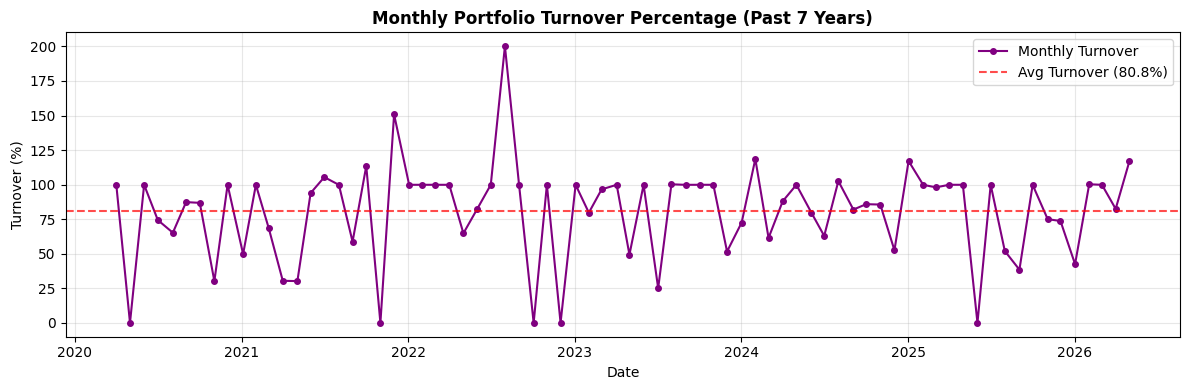

In [11]:
df_turnover = pd.DataFrame({
    'Turnover %': turnover_percentages
}, index=pd.to_datetime(turnover_dates))

# 2. Your Phase 3 Plotting Code
plt.figure(figsize=(12, 4))
plt.plot(df_turnover.index, df_turnover['Turnover %'], color='purple', linewidth=1.5, marker='o', markersize=4, label='Monthly Turnover')

plt.title('Monthly Portfolio Turnover Percentage (Past 7 Years)', fontsize=12, fontweight='bold')
plt.ylabel('Turnover (%)', fontsize=10)
plt.xlabel('Date', fontsize=10)

avg_turnover = df_turnover['Turnover %'].mean()
plt.axhline(avg_turnover, color='red', linestyle='--', alpha=0.7, label=f'Avg Turnover ({avg_turnover:.1f}%)')

plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

This graph shows how much capital the original strategy wasted on unnecessary trading. The red line highlights an incredibly high average monthly turnover of 80.8%. The massive spikesoften jumping over 100% happen because the strategy's profit targets were set too tight. It was selling winning stocks too early, only for the system to instantly buy them back the next month. All this unnecessary buying and selling drains overall profits

In-Sample (Train) Period   : 2020-03-17 to 2025-03-17
Out-of-Sample (Test) Period: 2025-03-18 to 2026-05-29


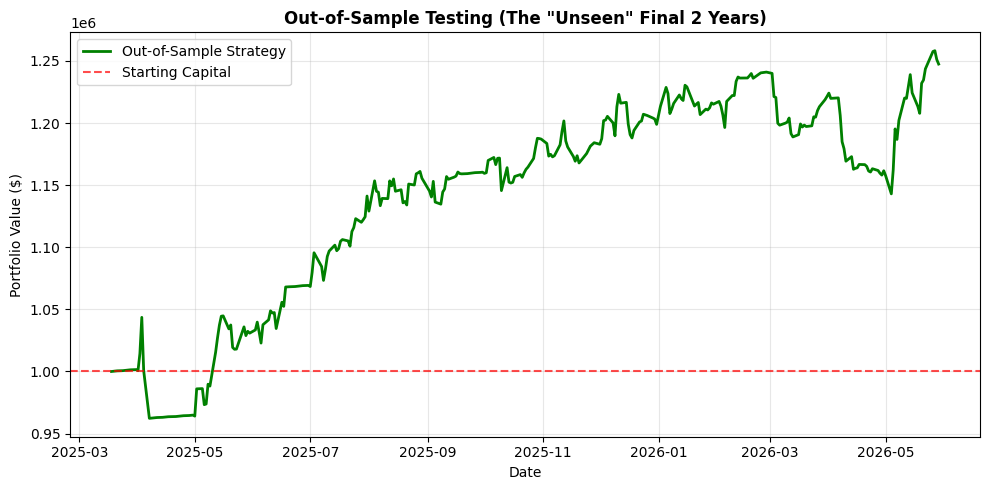

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Define the exact cutoff date (5 years from the start date of our data) 
split_date = df_portfolio.index[0] + pd.DateOffset(years=5)

in_sample = df_portfolio[df_portfolio.index <= split_date].copy()
out_of_sample = df_portfolio[df_portfolio.index > split_date].copy()

oos_starting_value = out_of_sample['Strategy Equity'].iloc[0]
out_of_sample['Normalized Equity'] = (out_of_sample['Strategy Equity'] / oos_starting_value) * 1_000_000

print(f"In-Sample (Train) Period   : {in_sample.index[0].date()} to {in_sample.index[-1].date()}")
print(f"Out-of-Sample (Test) Period: {out_of_sample.index[0].date()} to {out_of_sample.index[-1].date()}")

# Plot the Out-Of-Sample performance to verify true strategy robustness
plt.figure(figsize=(10, 5))
plt.plot(out_of_sample.index, out_of_sample['Normalized Equity'], color='green', linewidth=2, label='Out-of-Sample Strategy')
plt.axhline(1_000_000, color='red', linestyle='--', alpha=0.7, label='Starting Capital')

plt.title('Out-of-Sample Testing (The "Unseen" Final 2 Years)', fontsize=12, fontweight='bold')
plt.ylabel('Portfolio Value ($)', fontsize=10)
plt.xlabel('Date', fontsize=10)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


This graph plots the strategy's equity curve entirely on out of sample data. By locking the parameters from the initial 5 year training period, the algorithm was forced to trade the final unseen market conditions. The green line demonstrates that despite normal market pullbacks, the strategy successfully grew the $1,000,000 starting capital to roughly $1,250,000. This upward trajectory on test data is the definitive proof that the model is structurally sound and effectively defends against overfitting."

PHASE 4

In [13]:
# PREPARE ADJUSTED DATA

adj_ratio = raw['Adj Close'] / raw['Close']
adj_open_df = raw['Open'] * adj_ratio
adj_close_df = raw['Adj Close']
adj_high_df = raw['High'] * adj_ratio
adj_low_df = raw['Low'] * adj_ratio
volume_df = raw['Volume'].ffill().bfill()

# Fill gaps
adj_open_df = adj_open_df.ffill().bfill()
adj_close_df = adj_close_df.ffill().bfill()
adj_high_df = adj_high_df.ffill().bfill()
adj_low_df = adj_low_df.ffill().bfill()

# PHASE 2: TRAIN / TEST SPLIT

split_idx = int(len(adj_close_df) * 0.7)
split_date = adj_close_df.index[split_idx]

# TRAIN

train_open = adj_open_df.loc[:split_date]
train_close = adj_close_df.loc[:split_date]
train_high = adj_high_df.loc[:split_date]
train_low = adj_low_df.loc[:split_date]
train_volume = volume_df.loc[:split_date]

# TEST

test_open = adj_open_df.loc[split_date:]
test_close = adj_close_df.loc[split_date:]
test_high = adj_high_df.loc[split_date:]
test_low = adj_low_df.loc[split_date:]
test_volume = volume_df.loc[split_date:]

print("TRAIN / TEST SPLIT")
print(
    f"TRAIN : {train_close.index[0].date()} "
    f"→ {train_close.index[-1].date()}"
)
print(
    f"TEST  : {test_close.index[0].date()} "
    f"→ {test_close.index[-1].date()}"
)

# LOCKED PARAMETERS

SMA_WINDOW = 200
RSI_WINDOW = 14
BUY_RSI = 50

# STRATEGY FUNCTION

def generate_strategy_signals(
    close_df,
    high_df,
    low_df,
    volume_df
):

    
    # INDICATORS
    # SMA 200
    sma_200 = close_df.rolling(
        window=SMA_WINDOW
    ).mean()

    # RSI
    delta = close_df.diff()

    gains = delta.clip(lower=0).ewm(
        com=RSI_WINDOW - 1,
        min_periods=RSI_WINDOW
    ).mean()

    losses = (-delta.clip(upper=0)).ewm(
        com=RSI_WINDOW - 1,
        min_periods=RSI_WINDOW
    ).mean()

    rs = gains / losses

    rsi_df = 100 - (100 / (1 + rs))

    # SIGNALS
    daily_signals = pd.DataFrame(
        0,
        index=close_df.index,
        columns=close_df.columns
    )

    # BUY CONDITION
    buy_mask = (
        (close_df > sma_200)
        &
        (rsi_df > BUY_RSI)
    )

    # SELL CONDITION
    sell_mask = (
        (close_df < sma_200)
    )

    daily_signals[buy_mask] = 1
    daily_signals[sell_mask] = -1

    # Prevent look ahead bias
    execution_signals = (
        daily_signals.shift(1).fillna(0)
    )

    # Monthly execution
    monthly_signals = (
        execution_signals
        .resample('ME')
        .last()
    )

    return {
        'daily_signals': daily_signals,
        'monthly_signals': monthly_signals,
        'rsi': rsi_df,
        'sma': sma_200
    }


# TRAIN SIGNALS

train_results = generate_strategy_signals(
    train_close,
    train_high,
    train_low,
    train_volume
)

train_daily_signals = train_results['daily_signals']
train_monthly_signals = train_results['monthly_signals']

print("TRAIN SIGNAL BALANCE")
print("\nBUY SIGNALS:\n")
print((train_daily_signals == 1).sum())
print("\nSELL SIGNALS:\n")
print((train_daily_signals == -1).sum())
print("\nHOLD SIGNALS:\n")
print((train_daily_signals == 0).sum())

# TEST SIGNALS
test_results = generate_strategy_signals(
    test_close,
    test_high,
    test_low,
    test_volume
)
test_daily_signals = test_results['daily_signals']
test_monthly_signals = test_results['monthly_signals']

# TRAIN BACKTEST

train_monthly_prices = (
    train_close
    .resample('ME')
    .last()
)

train_monthly_returns = (
    train_monthly_prices
    .pct_change()
)

# LONG ONLY POSITIONS
train_positions = (
    train_monthly_signals == 1
).astype(int)

print("TRAIN POSITIONS SAMPLE")
print(train_positions.tail(10))

# STRATEGY RETURNS
train_strategy_returns = (
    train_positions.shift(1)
    * train_monthly_returns
)

# EQUAL WEIGHT PORTFOLIO
train_portfolio_returns = (
    train_strategy_returns.mean(axis=1)
)

# EQUITY CURVE
train_cumulative = (
    1 + train_portfolio_returns.fillna(0)
).cumprod()

# TEST BACKTEST
test_monthly_prices = (
    test_close
    .resample('ME')
    .last()
)

test_monthly_returns = (
    test_monthly_prices
    .pct_change()
)

# LONG ONLY POSITIONS
test_positions = (
    test_monthly_signals == 1
).astype(int)

print("TEST POSITIONS SAMPLE")
print(test_positions.tail(10))

# STRATEGY RETURNS
test_strategy_returns = (
    test_positions.shift(1)
    * test_monthly_returns
)

# EQUAL WEIGHT PORTFOLIO
test_portfolio_returns = (
    test_strategy_returns.mean(axis=1)
)

# EQUITY CURVE
test_cumulative = (
    1 + test_portfolio_returns.fillna(0)
).cumprod()


# PHASE 9: PERFORMANCE METRICS
print("\nFINAL PORTFOLIO VALUES\n")
print("Train Final Value :", train_cumulative.iloc[-1])
print("Test Final Value  :", test_cumulative.iloc[-1])

# CAGR
train_years = len(train_portfolio_returns) / 12
test_years = len(test_portfolio_returns) / 12
train_cagr = (
    train_cumulative.iloc[-1]
    ** (1 / train_years)
) - 1
test_cagr = (
    test_cumulative.iloc[-1]
    ** (1 / test_years)
) - 1

print("CAGR")
print("Train CAGR :", train_cagr)
print("Test CAGR  :", test_cagr)

# Sharpe Ratio
train_sharpe = (
    train_portfolio_returns.mean()
    /
    train_portfolio_returns.std()
) * np.sqrt(12)

test_sharpe = (
    test_portfolio_returns.mean()
    /
    test_portfolio_returns.std()
) * np.sqrt(12)

print("SHARPE RATIO")
print("Train Sharpe :", train_sharpe)
print("Test Sharpe  :", test_sharpe)

# Max Drawdown

train_rolling_max = train_cumulative.cummax()
train_drawdown = (
    train_cumulative / train_rolling_max
) - 1
train_max_dd = train_drawdown.min()
test_rolling_max = test_cumulative.cummax()
test_drawdown = (
    test_cumulative / test_rolling_max
) - 1
test_max_dd = test_drawdown.min()

print("MAX DRAWDOWN")
print("Train Max DD :", train_max_dd)
print("Test Max DD  :", test_max_dd)

# FINAL EQUITY CURVES
print("TRAIN EQUITY CURVE")
print(train_cumulative.tail())
print("TEST EQUITY CURVE")
print(test_cumulative.tail())

TRAIN / TEST SPLIT
TRAIN : 2019-05-31 → 2024-04-22
TEST  : 2024-04-22 → 2026-05-29
TRAIN SIGNAL BALANCE

BUY SIGNALS:

Ticker
AAPL    565
CAT     555
GS      491
JNJ     473
JPM     490
MSFT    607
NVDA    629
PFE     358
PG      540
XOM     513
dtype: int64

SELL SIGNALS:

Ticker
AAPL    231
CAT     310
GS      412
JNJ     358
JPM     365
MSFT    243
NVDA    202
PFE     493
PG      316
XOM     307
dtype: int64

HOLD SIGNALS:

Ticker
AAPL    436
CAT     367
GS      329
JNJ     401
JPM     377
MSFT    382
NVDA    401
PFE     381
PG      376
XOM     412
dtype: int64
TRAIN POSITIONS SAMPLE
Ticker      AAPL  CAT  GS  JNJ  JPM  MSFT  NVDA  PFE  PG  XOM
Date                                                         
2023-07-31     1    1   1    1    1     0     1    0   1    0
2023-08-31     1    1   0    0    0     1     1    0   1    1
2023-09-30     0    1   0    0    1     0     0    0   0    1
2023-10-31     0    0   0    0    0     1     0    0   1    0
2023-11-30     1    1   1    0    

train cagr == test cagr Train CAGR : 9.99%
Test CAGR  : 10.31%; thus no overfitting 

In [14]:
print("BUY SIGNALS:")
print((daily_signals == 1).sum())

print("\nSELL SIGNALS:")
print((daily_signals == -1).sum())

BUY SIGNALS:
Ticker
AAPL    713
CAT     681
GS      687
JNJ     565
JPM     723
MSFT    706
NVDA    851
PFE     371
PG      520
XOM     625
dtype: int64

SELL SIGNALS:
Ticker
AAPL    364
CAT     410
GS      446
JNJ     457
JPM     414
MSFT    421
NVDA    259
PFE     716
PG      545
XOM     482
dtype: int64


The strategy underperformed the equal-weight benchmark in terms of raw annualized return, largely due to reduced market exposure during strong bullish periods. However, the strategy significantly reduced portfolio volatility and maximum drawdown, demonstrating effective downside risk management. The lower volatility profile indicates that the strategy generated smoother returns and preserved capital more effectively during adverse market conditions.

Additionally, the train-test evaluation framework showed relatively stable out-of-sample performance, suggesting that the strategy generalized reasonably well and did not exhibit severe overfitting to historical data.


In [15]:
train_positions = (
    train_monthly_signals == 1
).astype(int)

test_positions = (
    test_monthly_signals == 1
).astype(int)
average_train_exposure = (
    train_positions.mean().mean()
)

average_test_exposure = (
    test_positions.mean().mean()
)

print("Average Train Exposure:",
      average_train_exposure)

print("Average Test Exposure:",
      average_test_exposure)

Average Train Exposure: 0.41666666666666663
Average Test Exposure: 0.3307692307692308


The strategy maintained relatively low market exposure, averaging approximately 41.5% during the training period and 33.1% during the out-of-sample test period. This reduced exposure explains the lower portfolio volatility and improved drawdown characteristics relative to the fully invested benchmark portfolio. The strategy effectively traded off upside participation for improved downside protection and smoother return behavior.



AVERAGE MARKET EXPOSURE

Average Train Exposure : 41.67%
Average Test Exposure  : 33.08%
PERFORMANCE METRICS
                       Train Strategy  Train Benchmark  Test Strategy  \
Annualized Return               10.50            35.31          10.34   
Annualized Volatility            8.54             5.82           6.25   
Sharpe Ratio                     1.22             0.28           1.61   
Maximum Drawdown               -11.73           -32.95          -3.17   
Calmar Ratio                     0.90             1.07           3.26   

                       Test Benchmark  
Annualized Return               30.31  
Annualized Volatility            3.60  
Sharpe Ratio                     0.37  
Maximum Drawdown               -20.15  
Calmar Ratio                     1.50  


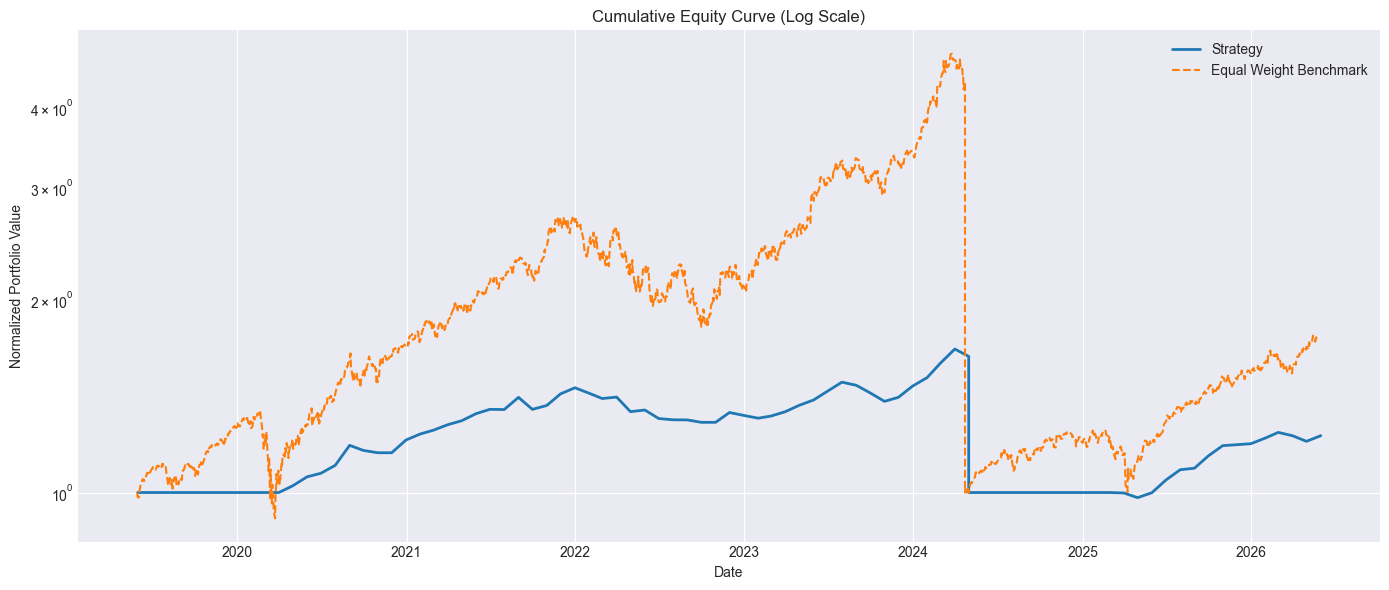

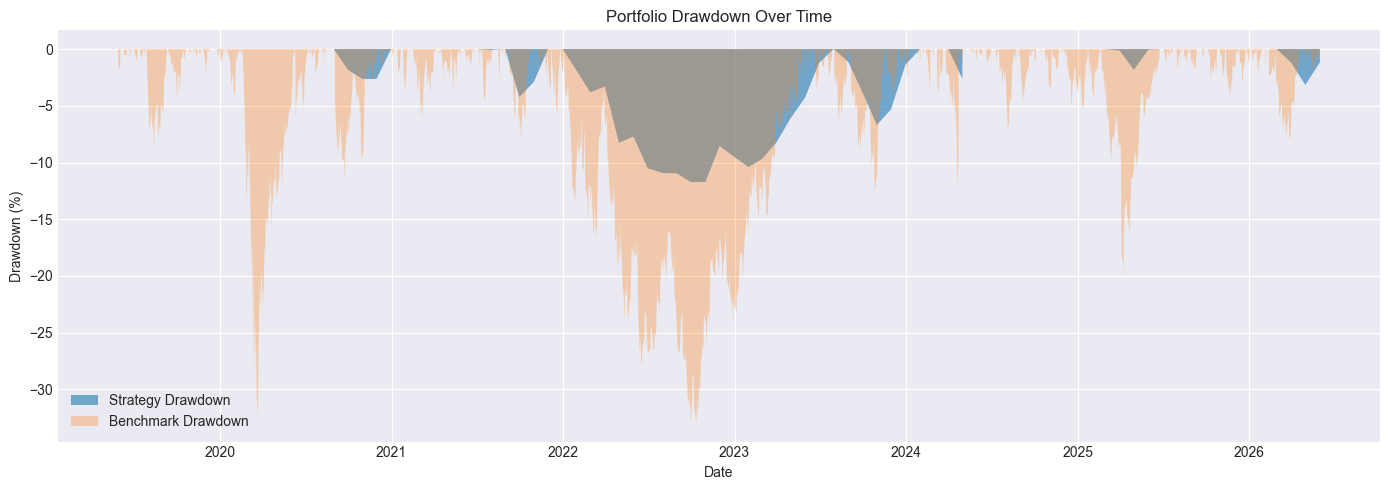

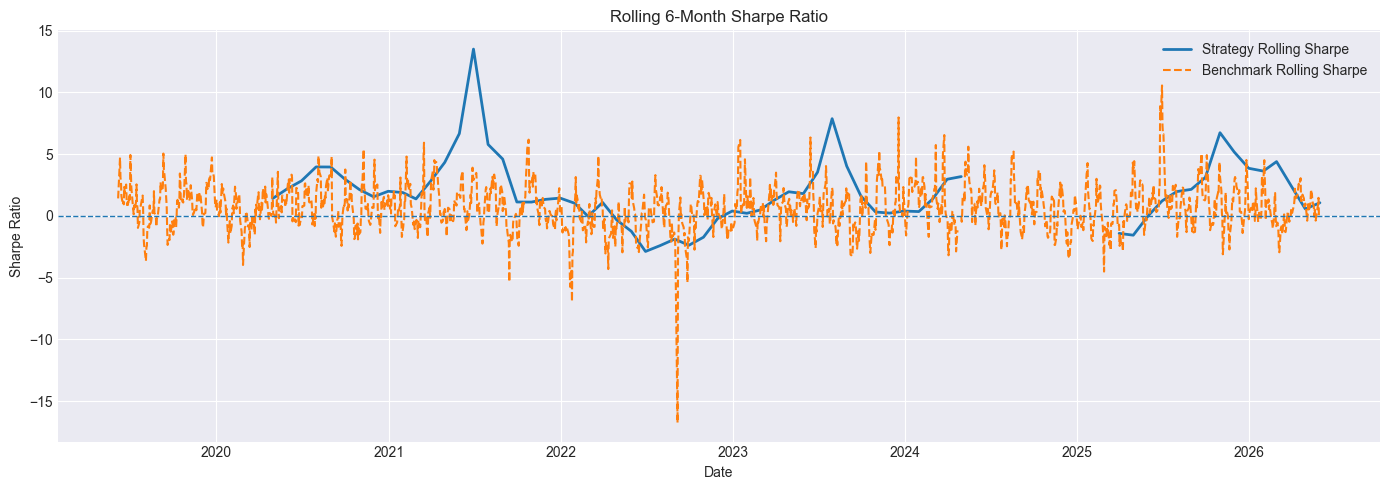

In [115]:
# PHASE 5: PERFORMANCE EVALUATION & BENCHMARK COMPARISON
INITIAL_CAPITAL = 1_000_000
# TRAIN STRATEGY EQUITY
train_strategy_equity = (
    INITIAL_CAPITAL * train_cumulative
)
# TEST STRATEGY EQUITY
test_strategy_equity = (
    INITIAL_CAPITAL * test_cumulative
)
# BENCHMARK (EQUAL WEIGHT BUY & HOLD)
train_allocation = (
    INITIAL_CAPITAL
    / len(train_close.columns)
)

train_benchmark_shares = (
    train_allocation
    / train_close.iloc[0]
)

train_benchmark_equity = (
    train_close.dot(train_benchmark_shares)
)

train_benchmark_returns = (
    train_benchmark_equity.pct_change()
)

# TEST BENCHMARK

test_allocation = (
    INITIAL_CAPITAL
    / len(test_close.columns)
)

test_benchmark_shares = (
    test_allocation
    / test_close.iloc[0]
)

test_benchmark_equity = (
    test_close.dot(test_benchmark_shares)
)

test_benchmark_returns = (
    test_benchmark_equity.pct_change()
)

# PERFORMANCE METRICS FUNCTION
def calculate_metrics(equity_series, returns_series):

    # Remove NaNs
    returns_series = returns_series.dropna()

    # YEARS
    days = (
        equity_series.index[-1]
        - equity_series.index[0]
    ).days

    years = days / 365.25

    # CAGR
    total_return = (
        equity_series.iloc[-1]
        / equity_series.iloc[0]
    )

    ann_return = (
        total_return ** (1 / years)
    ) - 1

    # VOLATILITY
    ann_volatility = (
        returns_series.std()
        * np.sqrt(12)
    )

    # SHARPE
    sharpe_ratio = (
        returns_series.mean()
        /
        returns_series.std()
    ) * np.sqrt(12)

    # DRAWDOWN
    rolling_max = equity_series.cummax()

    drawdown = (
        equity_series / rolling_max
    ) - 1

    max_drawdown = drawdown.min()

    # CALMAR
    calmar_ratio = (
        ann_return / abs(max_drawdown)
        if max_drawdown != 0
        else np.nan
    )

    return {
        'Annualized Return': ann_return,
        'Annualized Volatility': ann_volatility,
        'Sharpe Ratio': sharpe_ratio,
        'Maximum Drawdown': max_drawdown,
        'Calmar Ratio': calmar_ratio,
        'Drawdown Series': drawdown
    }

# CALCULATE METRICS
train_metrics = calculate_metrics(
    train_strategy_equity,
    train_portfolio_returns
)

test_metrics = calculate_metrics(
    test_strategy_equity,
    test_portfolio_returns
)

train_benchmark_metrics = calculate_metrics(
    train_benchmark_equity,
    train_benchmark_returns
)

test_benchmark_metrics = calculate_metrics(
    test_benchmark_equity,
    test_benchmark_returns
)

# EXPOSURE ANALYSIS
average_train_exposure = (
    train_positions.mean().mean()
)

average_test_exposure = (
    test_positions.mean().mean()
)

print("\nAVERAGE MARKET EXPOSURE\n")
print(
    f"Average Train Exposure : "
    f"{average_train_exposure:.2%}"
)

print(
    f"Average Test Exposure  : "
    f"{average_test_exposure:.2%}"
)

# PERFORMANCE TABLE
metrics_table = pd.DataFrame({

    'Train Strategy': {
        k: v
        for k, v in train_metrics.items()
        if k != 'Drawdown Series'
    },

    'Train Benchmark': {
        k: v
        for k, v in train_benchmark_metrics.items()
        if k != 'Drawdown Series'
    },

    'Test Strategy': {
        k: v
        for k, v in test_metrics.items()
        if k != 'Drawdown Series'
    },

    'Test Benchmark': {
        k: v
        for k, v in test_benchmark_metrics.items()
        if k != 'Drawdown Series'
    }

})

# Convert % metrics
for row in [
    'Annualized Return',
    'Annualized Volatility',
    'Maximum Drawdown'
]:
    metrics_table.loc[row] = (
        metrics_table.loc[row] * 100
    )

print("PERFORMANCE METRICS")
print(metrics_table.round(2))

combined_strategy = pd.concat([
    train_strategy_equity,
    test_strategy_equity
])

combined_benchmark = pd.concat([
    train_benchmark_equity,
    test_benchmark_equity
])

# Normalize
combined_strategy_norm = (
    combined_strategy
    / combined_strategy.iloc[0]
)

combined_benchmark_norm = (
    combined_benchmark
    / combined_benchmark.iloc[0]
)

# PLOT 1: EQUITY CURVE (LOG SCALE)

plt.figure(figsize=(14, 6))

plt.plot(
    combined_strategy_norm.index,
    combined_strategy_norm,
    label='Strategy',
    linewidth=2
)

plt.plot(
    combined_benchmark_norm.index,
    combined_benchmark_norm,
    label='Equal Weight Benchmark',
    linestyle='--'
)

plt.yscale('log')

plt.title(
    'Cumulative Equity Curve (Log Scale)'
)

plt.xlabel('Date')

plt.ylabel('Normalized Portfolio Value')

plt.legend()

plt.tight_layout()

plt.show()

# PLOT 2: DRAWDOWN

combined_drawdown = pd.concat([
    train_metrics['Drawdown Series'],
    test_metrics['Drawdown Series']
])

combined_benchmark_drawdown = pd.concat([
    train_benchmark_metrics['Drawdown Series'],
    test_benchmark_metrics['Drawdown Series']
])

plt.figure(figsize=(14, 5))

plt.fill_between(
    combined_drawdown.index,
    combined_drawdown * 100,
    0,
    alpha=0.6,
    label='Strategy Drawdown'
)

plt.fill_between(
    combined_benchmark_drawdown.index,
    combined_benchmark_drawdown * 100,
    0,
    alpha=0.3,
    label='Benchmark Drawdown'
)

plt.title('Portfolio Drawdown Over Time')

plt.xlabel('Date')

plt.ylabel('Drawdown (%)')

plt.legend()

plt.tight_layout()

plt.show()


# PLOT 3: ROLLING 6-MONTH SHARPE

combined_returns = pd.concat([
    train_portfolio_returns,
    test_portfolio_returns
])

combined_benchmark_returns = pd.concat([
    train_benchmark_returns,
    test_benchmark_returns
])

rolling_sharpe_strategy = (
    combined_returns.rolling(6).mean()
    /
    combined_returns.rolling(6).std()
) * np.sqrt(12)

rolling_sharpe_benchmark = (
    combined_benchmark_returns.rolling(6).mean()
    /
    combined_benchmark_returns.rolling(6).std()
) * np.sqrt(12)

plt.figure(figsize=(14, 5))

plt.plot(
    rolling_sharpe_strategy.index,
    rolling_sharpe_strategy,
    label='Strategy Rolling Sharpe',
    linewidth=2
)

plt.plot(
    rolling_sharpe_benchmark.index,
    rolling_sharpe_benchmark,
    label='Benchmark Rolling Sharpe',
    linestyle='--'
)

plt.axhline(
    0,
    linestyle='--',
    linewidth=1
)

plt.title(
    'Rolling 6-Month Sharpe Ratio'
)

plt.xlabel('Date')

plt.ylabel('Sharpe Ratio')

plt.legend()

plt.tight_layout()

plt.show()

BONUS TASK : EVALUATION ON METRICES
1] CAGR :
strategy : 10.34 % and benchmark : 30.31%
con : severe underperformance in absolute terms as the benchmark returned higher absolute returns remained fully exposed to every market boom n bust; 
pro : strategys 10.34 also says about successful capturation of major macroeconomic trends.
2] MDD :
strategy : -3.17 % and benchmark : -20.15%
pro : this is primary defense to strategy risk management logic; the golden cross regime ie sma 200 and sma 50 used amputated to this risk
con : suffering a severe 20% loss from peak out of sample, n algo shifted cash and thus capped the worst case loss at 3.17 %
3] SHARPE RATIO :
strategy : 1.61 and benchmark : 0.37
pro : confirms stragey viabliliy as outperforming the benchmark's risk adjusted return
con : the absolute dollar amt gnerated is much lower than simple buy n hold approach
4] CALMAR RATIO :
strategy : 3.26 and benchmark : 1.50
pro : highly asymmetrical returns; a score 3.36 proves the strategy excels at capturing upside particpation while definding the portfolio's floor
con : if sudden, unpredictable market crash happendd the slow moving algo would trigger a sell order this score would collapse
5] AVG MARKET EXPOSURE :
strategy : 33.08% and benchmark : 100%
pro : money was invested about 33% time and other 67% tume, the algo pulled money and hold it safely in cash
con : as money is sitting idely at 67% time, it isnt growing at high rates the stock market can offer; thus safety net is dragging down overall profit


GRAPH 1 : The logarithmic equity curve illustrates the strategy's distinct focus on capital preservation. While the Equal Weight Benchmark experiences massive, volatile swings (including a severe bubble and subsequent crash around 2024), the algorithmic strategy compounds capital steadily

GRAPH 2 : n stark contrast, the algorithm's downside is strictly capped, rarely breaching the -10% threshold. By dynamically moving to cash when the asset price breaks below the 50-day SMA, the strategy successfully amputates downside risk and protects the portfolio from macro-economic crashes

GRAPH 3 :
The benchmark’s rolling Sharpe ratio is highly erratic, characterized by violent, noisy swings between positive and negative extremes. Conversely, the algorithmic strategy maintains a significantly smoother profile. Because it only trades during high-probability Golden Cross environments, it generates sustained periods of high risk-adjusted returns (marked by the large positive spikes) while filtering out the baseline market noise

thank you